In [1]:
import matplotlib.pyplot as plt
import numpy as np
import math
import pandas as pd
import numpy as np
import torch
import torch.optim as optim
from variables import *
from ref import *
from read_complex_matrix import read_complex_matrix
from calculating_dynamic_resolution import *
torch.set_printoptions(precision=4)

matr = read_complex_matrix('ref_matrix.txt')
import timeit

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')


In [2]:
data = np.loadtxt('experiment.txt')

r = data[:, 1]
r2 = data[:, 1] + data[:, 2]
r1 = data[:, 1] - data[:, 2]
sigma = sigma+0.0
Ibkg=Ibkg+0.0
I0_plus = np.mean(r[r > 0.9*r1[0]][0:1+math.ceil(len(r[r > 0.9*r1[0]])*0.7)])
I0 = torch.tensor(I0_plus).requires_grad_(True) - Ibkg

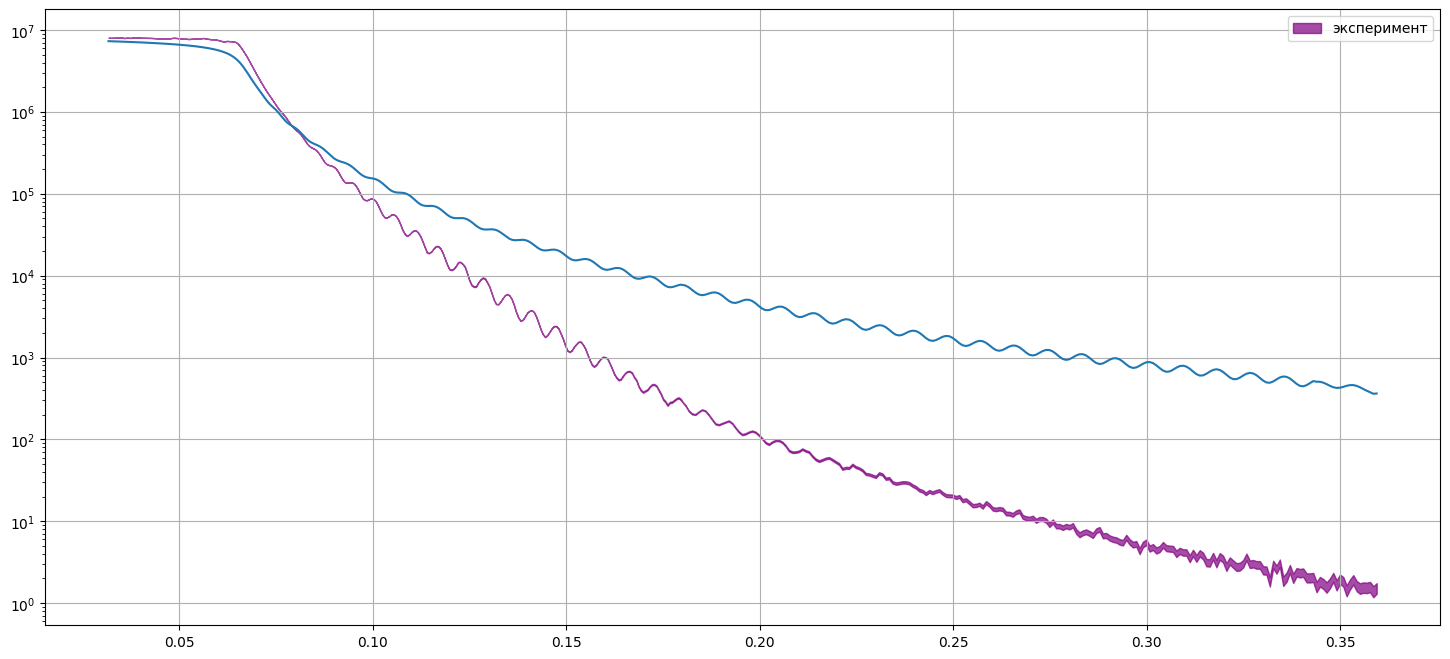

In [3]:
q = torch.pi*4.0e+10*torch.sin(torch.tensor(np.deg2rad(data[:, 0])))/1.524
r_mod, r_mod_conv= reflectometry(q, matr, sigma, sigma, I0, Ibkg)

fig, ax = plt.subplots(figsize=(18, 8))

ax.fill_between(q*1e-10, r1, r2, color='purple', alpha=0.7, label= 'эксперимент')
ax.plot(q.cpu().detach().numpy()[0:len(r_mod_conv.tolist())]*1e-10, (I0*r_mod_conv).tolist())
ax.set_yscale('log')

ax.legend()
plt.grid()
plt.show()

In [4]:
r = torch.tensor(data[:, 1], requires_grad = True)/I0
len(r)

467

In [5]:
from objective_function import *

loss_function = Comparator(q, matr, 10*sigma, 6*sigma, I0, Ibkg)

objective_function = varbounds(all_bounds, loss_function.compare)
objective_function_weightless = varbounds(all_bounds, loss_function.compare_weightless)

In [6]:
initial_d = torch.tensor([700.0,  15.0, 20.0,  0.0], requires_grad=True)
initial_rho = torch.tensor([4.02,  0.576], requires_grad=True)
initial_sigma = torch.tensor(0.01, requires_grad=True)

I_bounds =  torch.tensor([0.92*I0 , 1.08*I0]).requires_grad_(True)
Ibkg_bounds = torch.tensor([0.0, 3*Ibkg]).requires_grad_(True)

initial_sigma1 = torch.nn.Parameter(torch.tensor(0.01, dtype=torch.float64))
initial_sigma2 = torch.nn.Parameter(torch.tensor(0.01, dtype=torch.float64))
sigma_bounds1 =  torch.tensor([0.005 , 0.03]).requires_grad_(True)
sigma_bounds2 =  torch.tensor([0.005 , 0.03]).requires_grad_(True)

In [7]:
objective_function_weightless.objective_function(initial_d, initial_rho, sigma1, sigma2, I0, Ibkg)

tensor(463.3325, dtype=torch.float64, grad_fn=<SumBackward0>)

In [8]:
objective_function.objective_function(initial_d, initial_rho, sigma1, sigma2, I0, Ibkg)

tensor(40.6507, dtype=torch.float64, grad_fn=<SumBackward0>)

relative_loss:   1.0 
 d:   tensor([704.9999,  10.0063,  15.0001,  16.0000])     grad_d:   tensor([-4.0100e-04,  7.8905e-06,  5.5164e-04, -4.4669e-04]) 
 rho:   tensor([4.0250, 0.5710])     grad_rho:   tensor([-0.0690,  0.0074]) 
 sigma1:   tensor(0.0100, dtype=torch.float64)     grad_sigma1:   tensor(-0.0033, dtype=torch.float64, grad_fn=<DivBackward0>) 
 sigma2:   tensor(0.0100, dtype=torch.float64)     grad_sigma2:   tensor(-0.0004, dtype=torch.float64, grad_fn=<DivBackward0>) 
 I:   tensor(7331244.8710, dtype=torch.float64)     grad_I:   tensor(1.9188e-12, dtype=torch.float64) 
 Ibkg:   tensor(1.1999, dtype=torch.float64)     grad_Ibkg:   tensor(-1.3900e-05, dtype=torch.float64) 
 learning_rate:   5.0 
 iteration:   1 



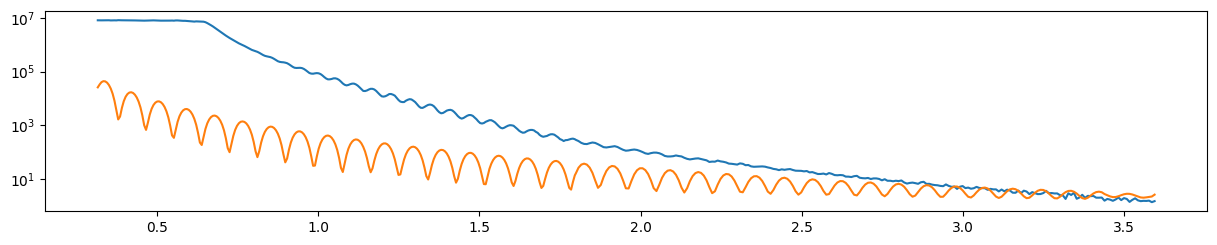

relative_loss:   0.9991661442929621 
 d:   tensor([755.0289,  50.0000,   7.5013,  16.0000])     grad_d:   tensor([-1.2997e-09, -7.1028e-04, -5.6772e-10,  1.2204e-04]) 
 rho:   tensor([4.0300, 0.6143])     grad_rho:   tensor([-0.0862, -0.0003]) 
 sigma1:   tensor(0.0109, dtype=torch.float64)     grad_sigma1:   tensor(-0.0015, dtype=torch.float64, grad_fn=<DivBackward0>) 
 sigma2:   tensor(0.0095, dtype=torch.float64)     grad_sigma2:   tensor(0.0017, dtype=torch.float64, grad_fn=<DivBackward0>) 
 I:   tensor(7331244.8710, dtype=torch.float64)     grad_I:   tensor(6.7982e-12, dtype=torch.float64) 
 Ibkg:   tensor(3.3000, dtype=torch.float64)     grad_Ibkg:   tensor(-1.5103e-05, dtype=torch.float64) 
 learning_rate:   3.234950917245001 
 iteration:   60 



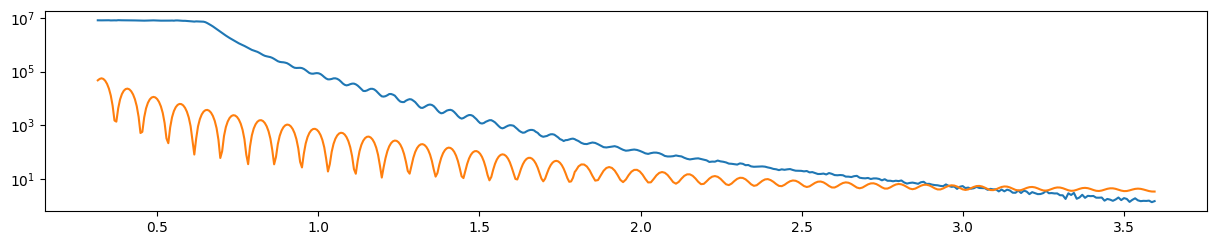

relative_loss:   0.9991658568777331 
 d:   tensor([755.0322,  50.0000,   7.5013,  16.0000])     grad_d:   tensor([ 7.7865e-09, -7.1030e-04, -3.6223e-10,  1.2073e-04]) 
 rho:   tensor([4.0300, 0.6500])     grad_rho:   tensor([-0.0862, -0.0003]) 
 sigma1:   tensor(0.0109, dtype=torch.float64)     grad_sigma1:   tensor(-0.0003, dtype=torch.float64, grad_fn=<DivBackward0>) 
 sigma2:   tensor(0.0092, dtype=torch.float64)     grad_sigma2:   tensor(0.0006, dtype=torch.float64, grad_fn=<DivBackward0>) 
 I:   tensor(7331244.8710, dtype=torch.float64)     grad_I:   tensor(6.7982e-12, dtype=torch.float64) 
 Ibkg:   tensor(3.3000, dtype=torch.float64)     grad_Ibkg:   tensor(-1.5103e-05, dtype=torch.float64) 
 learning_rate:   2.250517728383714 
 iteration:   119 



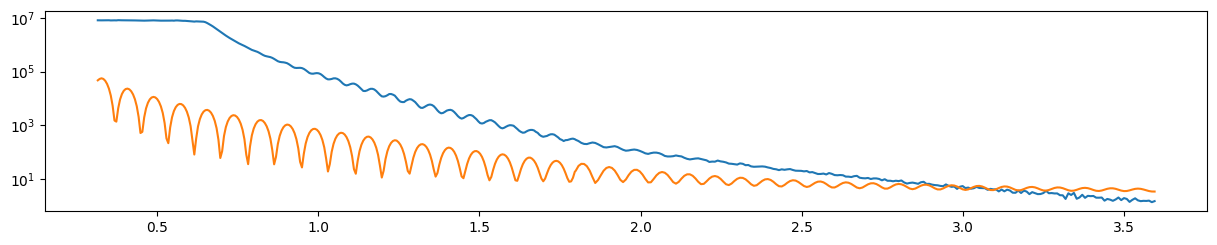

In [9]:
from optimizer import *
ans_d, ans_rho, ans_sigma1, ans_sigma2, ans_I, ans_Ibkg, loss, rel_losses1 = adamw(q, r, objective_function.objective_function, 
                                                                      initial_d, initial_rho, initial_sigma1, initial_sigma2, 1.0*I0, Ibkg, 
                                                                      d_bounds, rho_bounds, sigma_bounds1, sigma_bounds2, I_bounds, Ibkg_bounds,
                                                                      lr= 0.005, max_iter = 120, k=3)



relative_loss:   1.0 
 d:   tensor([754.2319,  49.2000,   6.7013,  16.0000])     grad_d:   tensor([0.0007, 0.0169, 0.0003, 0.0539]) 
 rho:   tensor([4.0300, 0.6500])     grad_rho:   tensor([-0.9162, -0.1466]) 
 sigma1:   tensor(0.0109, dtype=torch.float64)     grad_sigma1:   tensor(-0.0018, dtype=torch.float64, grad_fn=<DivBackward0>) 
 sigma2:   tensor(0.0087, dtype=torch.float64)     grad_sigma2:   tensor(0.6478, dtype=torch.float64, grad_fn=<DivBackward0>) 
 I:   tensor(7331244.8710, dtype=torch.float64)     grad_I:   tensor(2.0452e-07, dtype=torch.float64) 
 Ibkg:   tensor(3.3000, dtype=torch.float64)     grad_Ibkg:   tensor(-0.4544, dtype=torch.float64) 
 learning_rate:   0.8 
 iteration:   1 



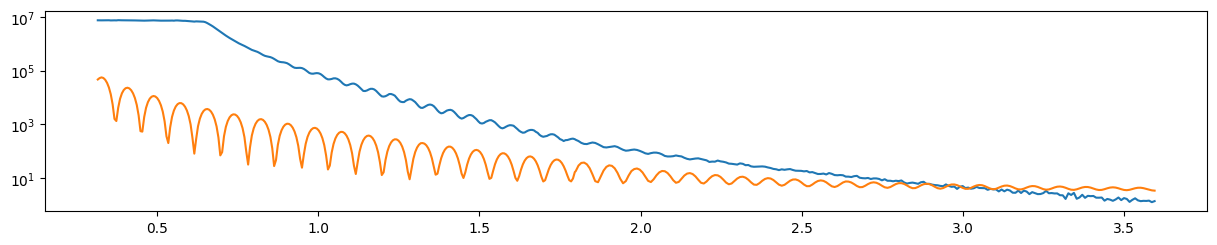

relative_loss:   0.9978696744539748 
 d:   tensor([748.0567,  18.8892,   7.4904,  16.0000])     grad_d:   tensor([-0.0002,  0.0001, -0.0002,  0.0544]) 
 rho:   tensor([4.0300, 0.6500])     grad_rho:   tensor([-1.4000, -0.1486]) 
 sigma1:   tensor(0.0104, dtype=torch.float64)     grad_sigma1:   tensor(-0.0037, dtype=torch.float64, grad_fn=<DivBackward0>) 
 sigma2:   tensor(0.0258, dtype=torch.float64)     grad_sigma2:   tensor(1.7813, dtype=torch.float64, grad_fn=<DivBackward0>) 
 I:   tensor(7331244.8710, dtype=torch.float64)     grad_I:   tensor(2.0404e-07, dtype=torch.float64) 
 Ibkg:   tensor(3.3000, dtype=torch.float64)     grad_Ibkg:   tensor(-0.4533, dtype=torch.float64) 
 learning_rate:   0.5175921467592002 
 iteration:   62 



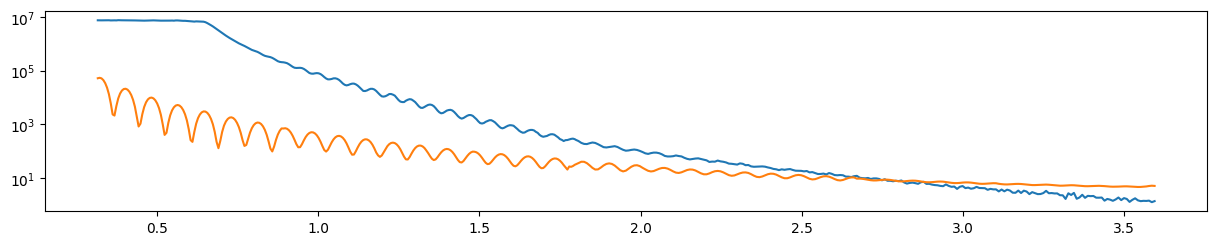

relative_loss:   0.9978861319887633 
 d:   tensor([749.4456,  18.8570,   7.4951,  16.0000])     grad_d:   tensor([-9.7530e-05,  9.5575e-05,  9.5241e-04,  5.3770e-02]) 
 rho:   tensor([4.0300, 0.6500])     grad_rho:   tensor([-1.3974, -0.1483]) 
 sigma1:   tensor(0.0105, dtype=torch.float64)     grad_sigma1:   tensor(0.0665, dtype=torch.float64, grad_fn=<DivBackward0>) 
 sigma2:   tensor(0.0195, dtype=torch.float64)     grad_sigma2:   tensor(2.4482, dtype=torch.float64, grad_fn=<DivBackward0>) 
 I:   tensor(7331244.8710, dtype=torch.float64)     grad_I:   tensor(2.0404e-07, dtype=torch.float64) 
 Ibkg:   tensor(3.3000, dtype=torch.float64)     grad_Ibkg:   tensor(-0.4533, dtype=torch.float64) 
 learning_rate:   0.3348770379834968 
 iteration:   123 



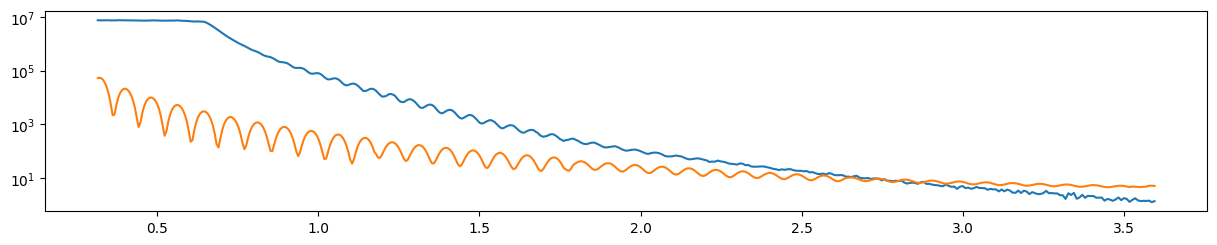

relative_loss:   0.9978791165500258 
 d:   tensor([749.7329,  18.8011,   7.5082,  16.0000])     grad_d:   tensor([-6.9499e-04,  6.9163e-05, -1.4962e-04,  5.4215e-02]) 
 rho:   tensor([4.0300, 0.6500])     grad_rho:   tensor([-1.3990, -0.1489]) 
 sigma1:   tensor(0.0107, dtype=torch.float64)     grad_sigma1:   tensor(-0.0376, dtype=torch.float64, grad_fn=<DivBackward0>) 
 sigma2:   tensor(0.0191, dtype=torch.float64)     grad_sigma2:   tensor(-6.0248, dtype=torch.float64, grad_fn=<DivBackward0>) 
 I:   tensor(7331244.8710, dtype=torch.float64)     grad_I:   tensor(2.0403e-07, dtype=torch.float64) 
 Ibkg:   tensor(3.3000, dtype=torch.float64)     grad_Ibkg:   tensor(-0.4533, dtype=torch.float64) 
 learning_rate:   0.2166621562378004 
 iteration:   184 



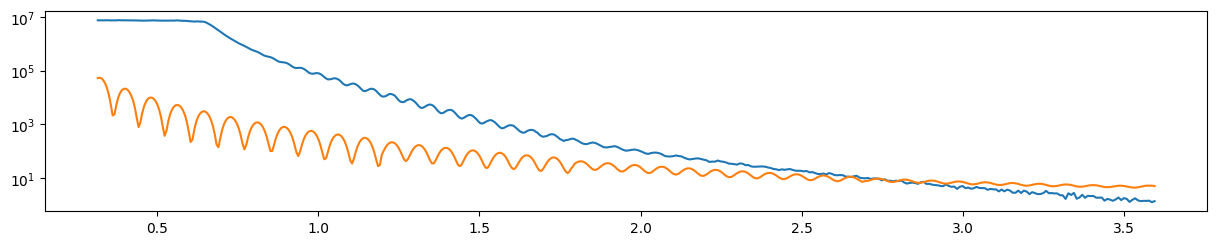

relative_loss:   0.9978661576296145 
 d:   tensor([749.1351,  18.8674,   7.5217,  16.0000])     grad_d:   tensor([-0.0007,  0.0003, -0.0009,  0.0546]) 
 rho:   tensor([4.0300, 0.6500])     grad_rho:   tensor([-1.4008, -0.1489]) 
 sigma1:   tensor(0.0106, dtype=torch.float64)     grad_sigma1:   tensor(-0.0236, dtype=torch.float64, grad_fn=<DivBackward0>) 
 sigma2:   tensor(0.0259, dtype=torch.float64)     grad_sigma2:   tensor(-0.0485, dtype=torch.float64, grad_fn=<DivBackward0>) 
 I:   tensor(7331244.8710, dtype=torch.float64)     grad_I:   tensor(2.0403e-07, dtype=torch.float64) 
 Ibkg:   tensor(3.3000, dtype=torch.float64)     grad_Ibkg:   tensor(-0.4533, dtype=torch.float64) 
 learning_rate:   0.14017828821075043 
 iteration:   245 



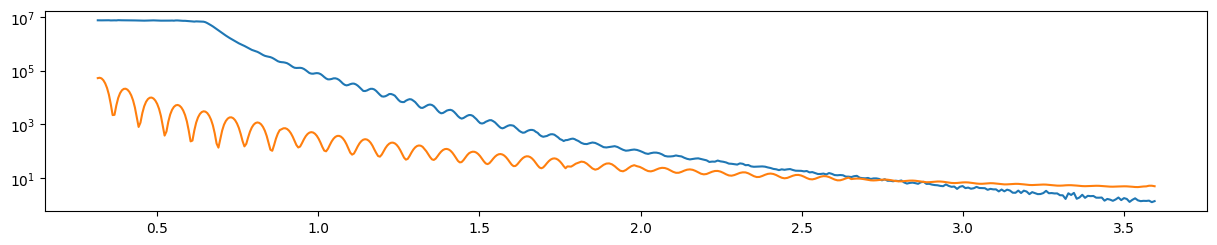

relative_loss:   0.9978908758012672 
 d:   tensor([749.1363,  18.8166,   7.5190,  16.0000])     grad_d:   tensor([-0.0009,  0.0003,  0.0007,  0.0536]) 
 rho:   tensor([4.0300, 0.6500])     grad_rho:   tensor([-1.3961, -0.1486]) 
 sigma1:   tensor(0.0106, dtype=torch.float64)     grad_sigma1:   tensor(0.0320, dtype=torch.float64, grad_fn=<DivBackward0>) 
 sigma2:   tensor(0.0194, dtype=torch.float64)     grad_sigma2:   tensor(-0.2501, dtype=torch.float64, grad_fn=<DivBackward0>) 
 I:   tensor(7331244.8710, dtype=torch.float64)     grad_I:   tensor(2.0403e-07, dtype=torch.float64) 
 Ibkg:   tensor(3.3000, dtype=torch.float64)     grad_Ibkg:   tensor(-0.4533, dtype=torch.float64) 
 learning_rate:   0.09069397640504023 
 iteration:   306 



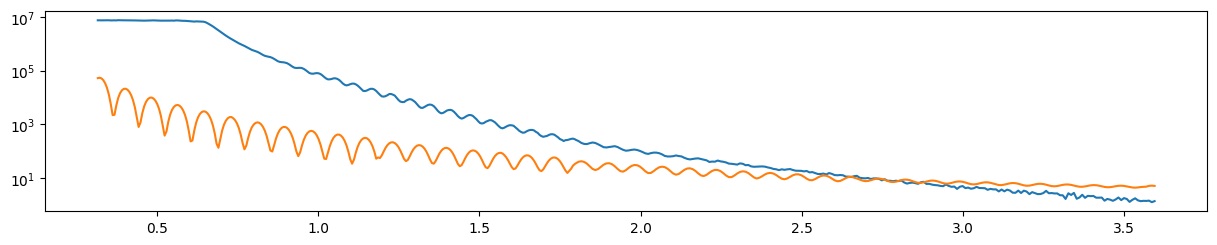

relative_loss:   0.9978909480598906 
 d:   tensor([749.6897,  18.8066,   7.4842,  16.0000])     grad_d:   tensor([ 0.0011, -0.0005,  0.0005,  0.0546]) 
 rho:   tensor([4.0300, 0.6500])     grad_rho:   tensor([-1.3967, -0.1484]) 
 sigma1:   tensor(0.0108, dtype=torch.float64)     grad_sigma1:   tensor(-0.0418, dtype=torch.float64, grad_fn=<DivBackward0>) 
 sigma2:   tensor(0.0112, dtype=torch.float64)     grad_sigma2:   tensor(-1.8146, dtype=torch.float64, grad_fn=<DivBackward0>) 
 I:   tensor(7331244.8710, dtype=torch.float64)     grad_I:   tensor(2.0403e-07, dtype=torch.float64) 
 Ibkg:   tensor(3.3000, dtype=torch.float64)     grad_Ibkg:   tensor(-0.4533, dtype=torch.float64) 
 learning_rate:   0.05867811243201627 
 iteration:   367 



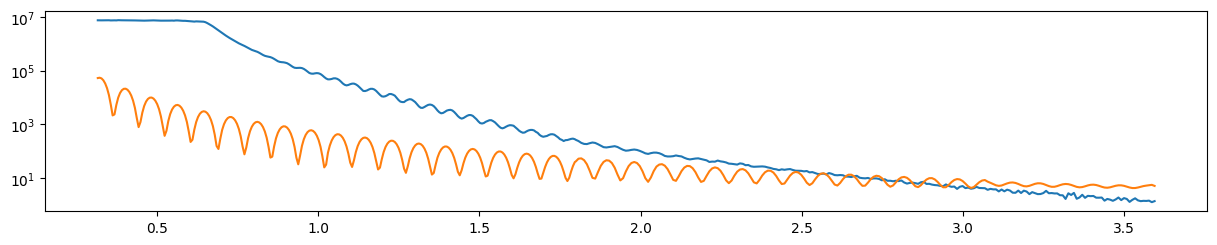

relative_loss:   0.997891437459361 
 d:   tensor([749.4337,  18.8234,   7.4815,  16.0000])     grad_d:   tensor([ 5.0660e-04, -4.0900e-05, -2.4584e-04,  5.4711e-02]) 
 rho:   tensor([4.0300, 0.6500])     grad_rho:   tensor([-1.3960, -0.1486]) 
 sigma1:   tensor(0.0111, dtype=torch.float64)     grad_sigma1:   tensor(-0.0373, dtype=torch.float64, grad_fn=<DivBackward0>) 
 sigma2:   tensor(0.0125, dtype=torch.float64)     grad_sigma2:   tensor(-3.7358, dtype=torch.float64, grad_fn=<DivBackward0>) 
 I:   tensor(7331244.8710, dtype=torch.float64)     grad_I:   tensor(2.0403e-07, dtype=torch.float64) 
 Ibkg:   tensor(3.3000, dtype=torch.float64)     grad_Ibkg:   tensor(-0.4533, dtype=torch.float64) 
 learning_rate:   0.037964162726831265 
 iteration:   428 



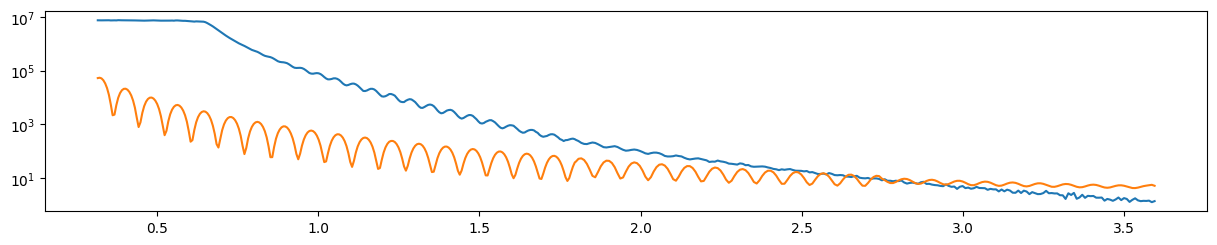

relative_loss:   0.9978787855103252 
 d:   tensor([749.4579,  18.7620,   7.4985,  16.0000])     grad_d:   tensor([-7.0768e-04, -1.1107e-05, -1.9398e-04,  5.4381e-02]) 
 rho:   tensor([4.0300, 0.6500])     grad_rho:   tensor([-1.3987, -0.1494]) 
 sigma1:   tensor(0.0110, dtype=torch.float64)     grad_sigma1:   tensor(0.0382, dtype=torch.float64, grad_fn=<DivBackward0>) 
 sigma2:   tensor(0.0133, dtype=torch.float64)     grad_sigma2:   tensor(-4.0794, dtype=torch.float64, grad_fn=<DivBackward0>) 
 I:   tensor(7331244.8710, dtype=torch.float64)     grad_I:   tensor(2.0402e-07, dtype=torch.float64) 
 Ibkg:   tensor(3.3000, dtype=torch.float64)     grad_Ibkg:   tensor(-0.4533, dtype=torch.float64) 
 learning_rate:   0.024562440607120255 
 iteration:   489 



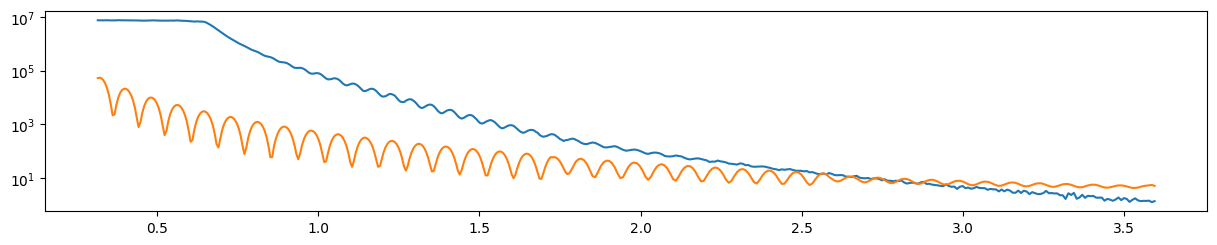

relative_loss:   0.9978746609720505 
 d:   tensor([749.5065,  18.8500,   7.4874,  16.0000])     grad_d:   tensor([ 0.0012, -0.0004,  0.0002,  0.0549]) 
 rho:   tensor([4.0300, 0.6500])     grad_rho:   tensor([-1.3997, -0.1488]) 
 sigma1:   tensor(0.0109, dtype=torch.float64)     grad_sigma1:   tensor(0.0004, dtype=torch.float64, grad_fn=<DivBackward0>) 
 sigma2:   tensor(0.0227, dtype=torch.float64)     grad_sigma2:   tensor(6.9078, dtype=torch.float64, grad_fn=<DivBackward0>) 
 I:   tensor(7331244.8710, dtype=torch.float64)     grad_I:   tensor(2.0403e-07, dtype=torch.float64) 
 Ibkg:   tensor(3.3000, dtype=torch.float64)     grad_Ibkg:   tensor(-0.4533, dtype=torch.float64) 
 learning_rate:   0.014779241897550994 
 iteration:   550 



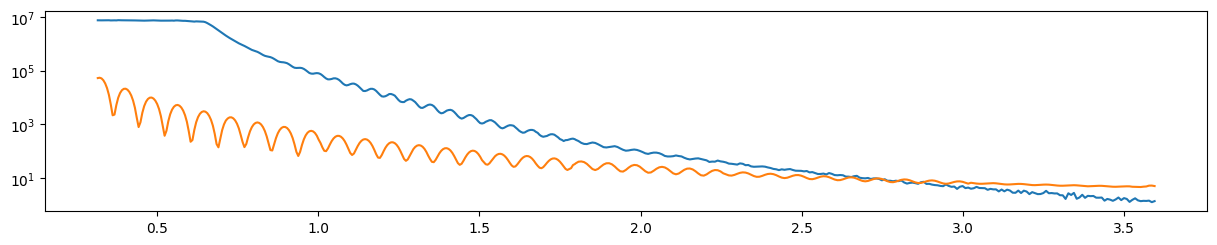

relative_loss:   0.9978919835793572 
 d:   tensor([749.2224,  18.8203,   7.4845,  16.0000])     grad_d:   tensor([ 8.0350e-04,  2.8781e-05, -4.0500e-08,  5.4748e-02]) 
 rho:   tensor([4.0300, 0.6500])     grad_rho:   tensor([-1.3955, -0.1487]) 
 sigma1:   tensor(0.0108, dtype=torch.float64)     grad_sigma1:   tensor(0.0084, dtype=torch.float64, grad_fn=<DivBackward0>) 
 sigma2:   tensor(0.0050, dtype=torch.float64)     grad_sigma2:   tensor(0.1031, dtype=torch.float64, grad_fn=<DivBackward0>) 
 I:   tensor(7331244.8710, dtype=torch.float64)     grad_I:   tensor(2.0403e-07, dtype=torch.float64) 
 Ibkg:   tensor(3.3000, dtype=torch.float64)     grad_Ibkg:   tensor(-0.4533, dtype=torch.float64) 
 learning_rate:   0.009562024426533667 
 iteration:   611 



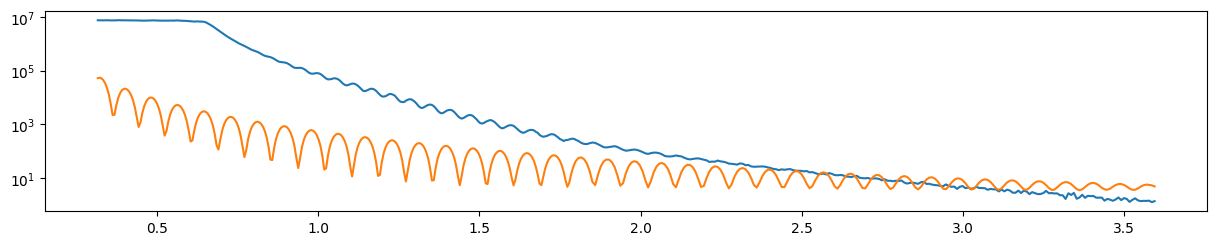

relative_loss:   0.9978915957736254 
 d:   tensor([748.8955,  18.8021,   7.4902,  16.0000])     grad_d:   tensor([ 2.9717e-04,  3.7380e-06, -9.7145e-07,  5.4539e-02]) 
 rho:   tensor([4.0300, 0.6500])     grad_rho:   tensor([-1.3956, -0.1488]) 
 sigma1:   tensor(0.0106, dtype=torch.float64)     grad_sigma1:   tensor(0.0037, dtype=torch.float64, grad_fn=<DivBackward0>) 
 sigma2:   tensor(0.0050, dtype=torch.float64)     grad_sigma2:   tensor(0.1259, dtype=torch.float64, grad_fn=<DivBackward0>) 
 I:   tensor(7331244.8710, dtype=torch.float64)     grad_I:   tensor(2.0403e-07, dtype=torch.float64) 
 Ibkg:   tensor(3.3000, dtype=torch.float64)     grad_Ibkg:   tensor(-0.4533, dtype=torch.float64) 
 learning_rate:   0.006186535937866838 
 iteration:   672 



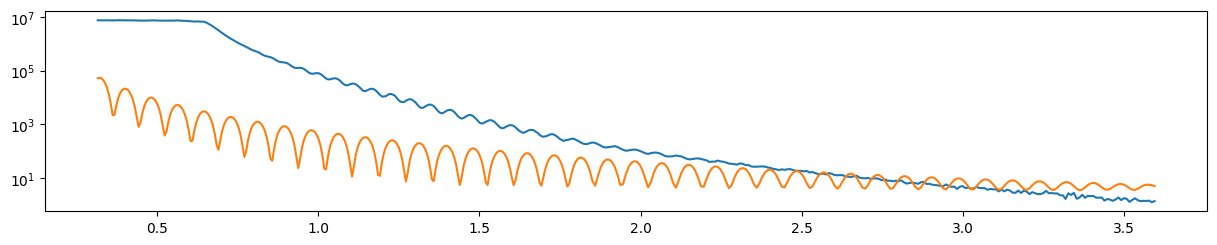

In [10]:
ans_d, ans_rho, ans_sigma1, ans_sigma2, ans_I, ans_Ibkg, loss, rel_losses2 = adamw(q, r, objective_function_weightless.objective_function, 
                                                                      ans_d, ans_rho, ans_sigma1, ans_sigma2, ans_I, ans_Ibkg, 
                                                                      d_bounds, rho_bounds, sigma_bounds1, sigma_bounds2, I_bounds, Ibkg_bounds,
                                                                      lr= 0.0008, max_iter = 680, k=12)


In [11]:
rel_losses2 = list(map(lambda x: x * rel_losses1[-1],  rel_losses2))
rel_losses3 = rel_losses1 + rel_losses2

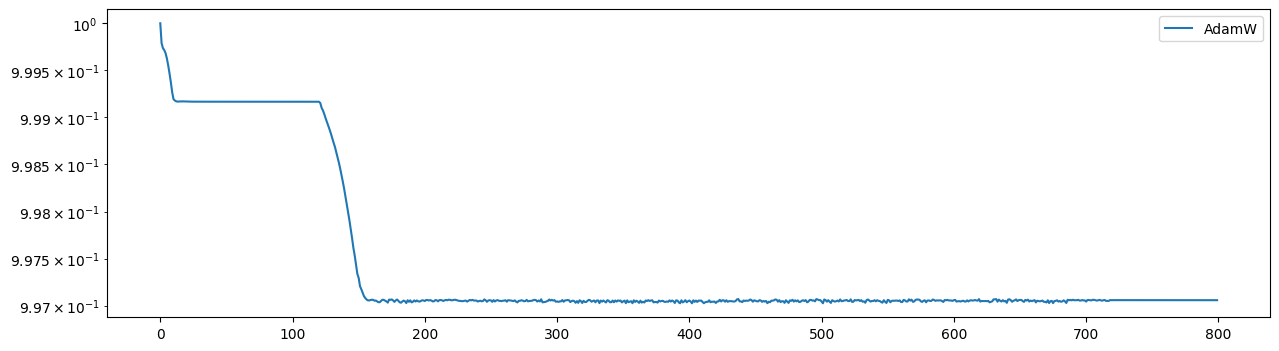

In [12]:
fig, ax = plt.subplots(figsize =(15, 4))

ax.plot(range(0,len(rel_losses3)), rel_losses3, label='AdamW')

ax.set_yscale('log')
ax.legend()
plt.show()